# Demo 12 — Heston Monte Carlo convergence

## Purpose

This notebook validates the public Heston Monte Carlo workflow against the semi-analytic Fourier pricer for a vanilla option.

It deliberately avoids notebook-local model or simulation code. The point is to show that the installed library already supports a reproducible validation loop:

- Andersen QE is treated as the production candidate.
- Full-truncation Euler is retained only as a baseline / educational comparison.
- The reference price is the library Fourier Heston pricer, not Black-Scholes.
- Every Monte Carlo estimate carries a fixed seed, path count, timestep count, standard error, and a 95% confidence interval.

The repo's Heston Monte Carlo reading path points to Andersen QE for production-style validation, so that is the method defended here.

The vanilla control variate is intentionally left off here so the raw Monte Carlo behavior is visible.

This notebook is intended to be run from a clean repository environment after installing the package in editable mode with `pip install -e .`. The local `src/` path fallback below is only for notebook convenience during development.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def _find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "src" / "option_pricing").exists():
            return candidate
    return start


ROOT = _find_repo_root(Path.cwd())
SRC = ROOT / "src"
if SRC.exists() and str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

In [2]:
from option_pricing import MarketData, OptionType
from option_pricing.diagnostics.heston import (
    HestonMCComparisonCase,
    HestonMCSweepConfig,
    compare_heston_mc_schemes,
    run_heston_mc_comparison_sweep,
    summarize_bias_vs_timestep,
    summarize_runtime_vs_error,
)
from option_pricing.models.heston import HestonParams
from option_pricing.monte_carlo import MCConfig, MonteCarloResult, RandomConfig
from option_pricing.pricers.heston import heston_price_call_from_ctx
from option_pricing.pricers.heston_mc import heston_mc_price_from_ctx

SEED = 12345
PATH_COUNTS = (2_000, 5_000, 10_000, 25_000, 50_000)
QE_STEPS = 128
TIMESTEP_GRID = (12, 24, 52, 104, 252)
TIMESTEP_SWEEP_PATHS = 16_000
TIMESTEP_SWEEP_REPEATS = 3

SCHEME_LABELS = {
    "quadratic_exponential": "Andersen QE",
    "euler_full_truncation": "Full-truncation Euler",
}

pd.set_option("display.precision", 6)

## Model and contract setup

We use the canonical `option_pricing.models.heston.HestonParams` object.

In the codebase the Heston names are:

- `vbar` -> long-run variance, often written `theta`
- `eta` -> volatility of variance, often written `xi`
- `v` -> initial variance, often written `v0`

The case below matches the public Heston MC test surface: an ATM one-year call with negative spot/variance correlation.

In [3]:
SPOT = 100.0
STRIKE = 100.0
TAU = 1.0
KIND = OptionType.CALL
MARKET = MarketData(spot=SPOT, rate=0.02, dividend_yield=0.0)
CTX = MARKET.to_context()
PARAMS = HestonParams(kappa=2.0, vbar=0.04, eta=0.55, rho=-0.70, v=0.05)


def _mc_cfg(n_paths: int, seed: int) -> MCConfig:
    return MCConfig(
        n_paths=int(n_paths),
        antithetic=True,
        random=RandomConfig(seed=int(seed)),
    )


def _run_mc(*, scheme: str, n_paths: int, n_steps: int, seed: int) -> MonteCarloResult:
    return heston_mc_price_from_ctx(
        ctx=CTX,
        kind=KIND,
        strike=STRIKE,
        params=PARAMS,
        tau=TAU,
        n_steps=int(n_steps),
        scheme=scheme,
        cfg=_mc_cfg(n_paths=n_paths, seed=seed),
    )


def _result_row(
    result: MonteCarloResult,
    *,
    scheme: str,
    n_steps: int,
    n_paths: int,
    seed: int,
    reference_price: float,
) -> dict[str, object]:
    ci = result.confidence_interval()
    abs_error = abs(float(result.price) - float(reference_price))
    error_in_stderr = (
        abs_error / float(result.stderr) if result.stderr > 0.0 else float("nan")
    )
    return {
        "scheme": scheme,
        "n_paths": int(n_paths),
        "effective_n": int(result.effective_n),
        "n_steps": int(n_steps),
        "seed": int(seed if result.seed is None else result.seed),
        "price": float(result.price),
        "stderr": float(result.stderr),
        "ci_low": float(ci.low),
        "ci_high": float(ci.high),
        "ci_half_width": float(ci.half_width),
        "reference_price": float(reference_price),
        "abs_error": abs_error,
        "error_in_stderr": error_in_stderr,
        "covered_reference": bool(ci.low <= reference_price <= ci.high),
    }


display(
    pd.DataFrame(
        [
            {
                "spot": SPOT,
                "strike": STRIKE,
                "tau": TAU,
                "rate": MARKET.rate,
                "dividend yield": MARKET.dividend_yield,
                "kappa": PARAMS.kappa,
                "vbar / theta": PARAMS.vbar,
                "eta / xi": PARAMS.eta,
                "rho": PARAMS.rho,
                "v / v0": PARAMS.v,
                "feller gap": 2.0 * PARAMS.kappa * PARAMS.vbar - PARAMS.eta**2,
            }
        ]
    )
)

,spot,strike,tau,rate,dividend yield,kappa,vbar / theta,eta / xi,rho,v / v0,feller gap
0,100.0,100.0,1.0,0.02,0.0,2.0,0.04,0.55,-0.7,0.05,-0.1425


**Note on the negative Feller gap**

This parameter set violates the strict Feller condition, so the reported `feller_gap` is negative. That is intentional for this demo: realistic calibrated Heston parameters often violate Feller, and a robust Monte Carlo implementation should still behave sensibly in this regime. That does not make the caveat disappear; it means the simulation engine still needs to be checked explicitly against the semi-analytic Fourier benchmark and judged against its reported uncertainty.

## Semi-analytic benchmark

The reference price comes from the public Fourier Heston pricer.

For vanilla validation, this is the right benchmark. The library also supports a semi-analytic vanilla control variate, but it stays off in this notebook because the goal is to inspect the raw MC estimator rather than hide its variance.

In [4]:
FOURIER_PRICE = float(
    heston_price_call_from_ctx(
        strike=STRIKE,
        ctx=CTX,
        tau=TAU,
        params=PARAMS,
    )
)

MAIN_QE_RUN = _run_mc(
    scheme="quadratic_exponential",
    n_paths=PATH_COUNTS[-1],
    n_steps=QE_STEPS,
    seed=SEED,
 )
main_ci = MAIN_QE_RUN.confidence_interval()

display(
    pd.DataFrame(
        [
            {
                "reference_pricer": "Heston Fourier",
                "reference_price": FOURIER_PRICE,
                "main_qe_price": MAIN_QE_RUN.price,
                "main_qe_stderr": MAIN_QE_RUN.stderr,
                "main_qe_ci_low_95": main_ci.low,
                "main_qe_ci_high_95": main_ci.high,
                "inside_95_ci": bool(main_ci.low <= FOURIER_PRICE <= main_ci.high),
                "n_steps": QE_STEPS,
                "n_paths": MAIN_QE_RUN.n_paths,
                "effective_n": MAIN_QE_RUN.effective_n,
                "seed": MAIN_QE_RUN.seed,
            }
        ]
    )
)

,reference_pricer,reference_price,main_qe_price,main_qe_stderr,main_qe_ci_low_95,main_qe_ci_high_95,inside_95_ci,n_steps,n_paths,effective_n,seed
0,Heston Fourier,8.629359,8.617213,0.032802,8.552922,8.681503,True,128,50000,25000,12345


With antithetic variates enabled, `n_paths` is the requested/generated path count, while `effective_n` is the number of averaged antithetic payoff pairs used for the standard-error estimate. This is why `effective_n` can be smaller than `n_paths`.

## QE convergence with path count

Only the QE path count changes here. The timestep count, seed, market, and Heston parameters stay fixed so the table and plot isolate Monte Carlo sampling error.

,n_paths,effective_n,n_steps,seed,price,stderr,ci_low,ci_high,ci_half_width,abs_error,error_in_stderr,covered_reference
0,2000,1000,128,12345,8.823563,0.167176,8.495905,9.151222,0.327658,0.194204,1.161674,True
1,5000,2500,128,12345,8.564728,0.104108,8.360680,8.768776,0.204048,0.064631,0.620812,True
2,10000,5000,128,12345,8.741905,0.074264,8.596350,8.887461,0.145555,0.112546,1.515483,True
3,25000,12500,128,12345,8.616030,0.046838,8.524229,8.707831,0.091801,0.013329,0.284580,True
4,50000,25000,128,12345,8.617213,0.032802,8.552922,8.681503,0.064291,0.012147,0.370305,True


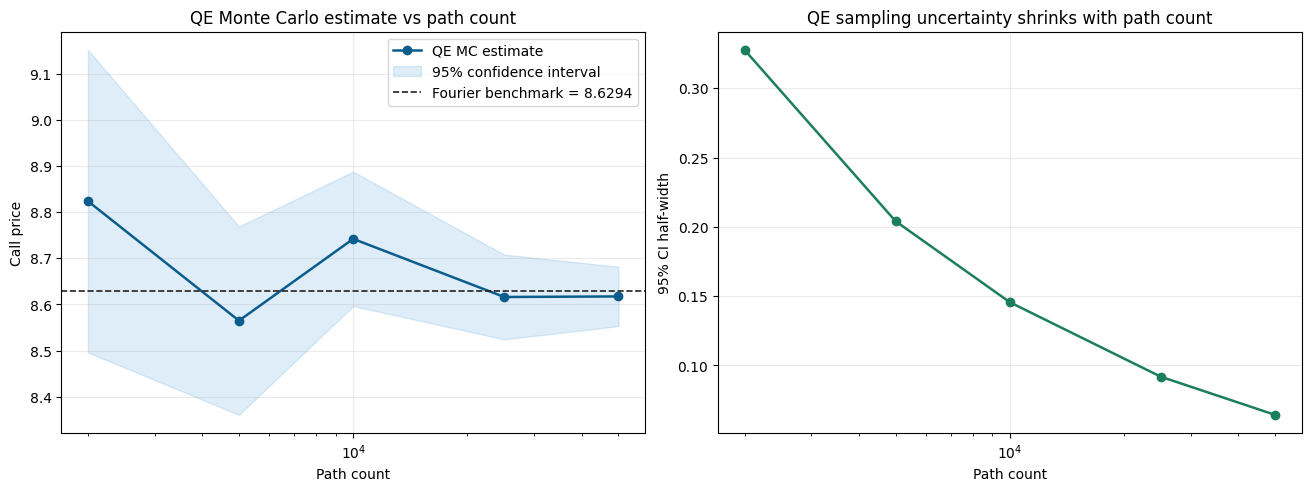

In [5]:
qe_rows = []
for n_paths in PATH_COUNTS:
    qe_result = _run_mc(
        scheme="quadratic_exponential",
        n_paths=n_paths,
        n_steps=QE_STEPS,
        seed=SEED,
    )
    qe_rows.append(
        _result_row(
            qe_result,
            scheme="quadratic_exponential",
            n_steps=QE_STEPS,
            n_paths=n_paths,
            seed=SEED,
            reference_price=FOURIER_PRICE,
        )
    )

qe_path_count = pd.DataFrame(qe_rows)
display(
    qe_path_count[
        [
            "n_paths",
            "effective_n",
            "n_steps",
            "seed",
            "price",
            "stderr",
            "ci_low",
            "ci_high",
            "ci_half_width",
            "abs_error",
            "error_in_stderr",
            "covered_reference",
        ]
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)

axes[0].plot(
    qe_path_count["n_paths"],
    qe_path_count["price"],
    marker="o",
    linewidth=1.8,
    color="#0b5d8c",
    label="QE MC estimate",
)
axes[0].fill_between(
    qe_path_count["n_paths"],
    qe_path_count["ci_low"],
    qe_path_count["ci_high"],
    color="#4c9ed9",
    alpha=0.18,
    label="95% confidence interval",
)
axes[0].axhline(
    FOURIER_PRICE,
    linestyle="--",
    linewidth=1.2,
    color="#222222",
    label=f"Fourier benchmark = {FOURIER_PRICE:.4f}",
)
axes[0].set_xscale("log")
axes[0].set_xlabel("Path count")
axes[0].set_ylabel("Call price")
axes[0].set_title("QE Monte Carlo estimate vs path count")
axes[0].grid(True, alpha=0.25)
axes[0].legend()

axes[1].plot(
    qe_path_count["n_paths"],
    qe_path_count["ci_half_width"],
    marker="o",
    linewidth=1.8,
    color="#1b7f5a",
)
axes[1].set_xscale("log")
axes[1].set_xlabel("Path count")
axes[1].set_ylabel("95% CI half-width")
axes[1].set_title("QE sampling uncertainty shrinks with path count")
axes[1].grid(True, alpha=0.25)

plt.show()

Monte Carlo point estimates are not expected to converge monotonically for one fixed random seed. What should shrink with path count is the sampling uncertainty, measured by the standard error or confidence-interval width.

**Figure takeaway:** QE estimates fluctuate around the Fourier benchmark, while the confidence intervals narrow as the number of paths increases.

**Figure takeaway:** Sampling uncertainty decreases with path count, which is the expected Monte Carlo convergence behavior.

## Euler vs QE timestep bias

Sampling error and discretization error are different questions. This sweep holds the path count fixed and changes only the timestep grid, then averages over deterministic seeds so the scheme comparison is less noisy.

This is a lightweight notebook-scale experiment, not a full benchmarking study. The goal is to show the qualitative bias and stability difference between Euler and QE while keeping runtime reasonable.

The recommendation logic in the library is deliberately conservative:

- `quadratic_exponential` -> production candidate
- `euler_full_truncation` -> baseline / educational

,scheme,n_steps,mean_price,mean_abs_error,rmse,mean_stderr,mean_ci_half_width,coverage_rate,repeat_count
0,euler_full_truncation,12,9.022072,0.392713,0.394141,0.066078,0.129511,0.000000,3
1,euler_full_truncation,24,8.868826,0.239466,0.243223,0.062640,0.122773,0.000000,3
2,euler_full_truncation,52,8.767935,0.138576,0.139756,0.060835,0.119234,0.333333,3
3,euler_full_truncation,104,8.707598,0.078238,0.091822,0.059639,0.116891,1.000000,3
4,euler_full_truncation,252,8.700072,0.070713,0.076433,0.058798,0.115241,1.000000,3
5,quadratic_exponential,12,8.655092,0.050827,0.057484,0.058517,0.114691,1.000000,3
6,quadratic_exponential,24,8.551101,0.078258,0.088452,0.058023,0.113723,1.000000,3
7,quadratic_exponential,52,8.684784,0.055425,0.063066,0.058998,0.115635,1.000000,3
8,quadratic_exponential,104,8.622303,0.046803,0.055531,0.058157,0.113986,1.000000,3
9,quadratic_exponential,252,8.665087,0.051047,0.055521,0.058537,0.114731,1.000000,3


,scheme,best_n_steps_by_abs_error,best_mean_abs_error,runtime_at_best_error,coverage_rate_at_best_error,recommended_use
0,euler_full_truncation,252,0.070713,0.135015,1.0,baseline / educational
1,quadratic_exponential,104,0.046803,0.185915,1.0,production candidate


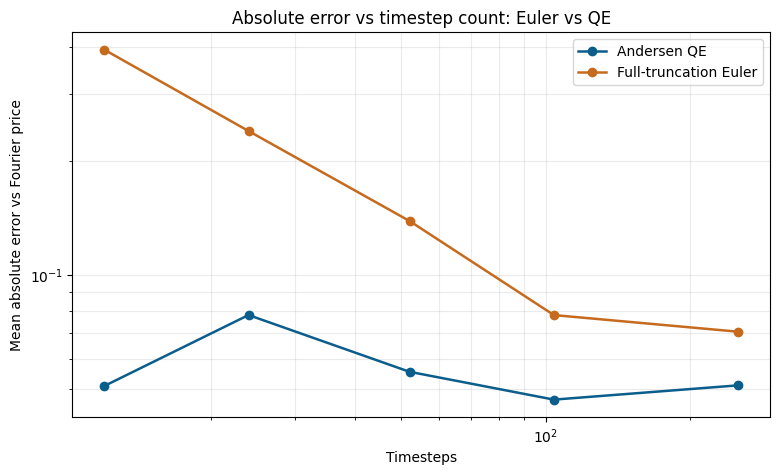

In [6]:
comparison_case = HestonMCComparisonCase(
    ctx=CTX,
    params=PARAMS,
    kind=KIND,
    strike=STRIKE,
    tau=TAU,
    reference_price=FOURIER_PRICE,
)
timestep_config = HestonMCSweepConfig(
    schemes=("euler_full_truncation", "quadratic_exponential"),
    n_steps_grid=TIMESTEP_GRID,
    n_paths=TIMESTEP_SWEEP_PATHS,
    seed=SEED,
    antithetic=True,
    repeats=TIMESTEP_SWEEP_REPEATS,
    use_control_variate=False,
)

timestep_sweep = run_heston_mc_comparison_sweep(comparison_case, timestep_config)
bias_summary = summarize_bias_vs_timestep(timestep_sweep)
runtime_summary = summarize_runtime_vs_error(timestep_sweep)
scheme_comparison = compare_heston_mc_schemes(timestep_sweep)

display(
    bias_summary[
        [
            "scheme",
            "n_steps",
            "mean_price",
            "mean_abs_error",
            "rmse",
            "mean_stderr",
            "mean_ci_half_width",
            "coverage_rate",
            "repeat_count",
        ]
    ].sort_values(["scheme", "n_steps"], ignore_index=True)
)

display(
    scheme_comparison[
        [
            "scheme",
            "best_n_steps_by_abs_error",
            "best_mean_abs_error",
            "runtime_at_best_error",
            "coverage_rate_at_best_error",
            "recommended_use",
        ]
    ].sort_values("scheme", ignore_index=True)
)

fig, ax = plt.subplots(figsize=(9, 5))
for scheme, color in (
    ("quadratic_exponential", "#0b5d8c"),
    ("euler_full_truncation", "#c66a1e"),
):
    scheme_rows = bias_summary.loc[bias_summary["scheme"] == scheme].sort_values("n_steps")
    ax.plot(
        scheme_rows["n_steps"],
        scheme_rows["mean_abs_error"],
        marker="o",
        linewidth=1.8,
        color=color,
        label=SCHEME_LABELS[scheme],
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Timesteps")
ax.set_ylabel("Mean absolute error vs Fourier price")
ax.set_title("Absolute error vs timestep count: Euler vs QE")
ax.grid(True, alpha=0.25, which="both")
ax.legend()
plt.show()

Narrow confidence intervals do not remove discretization bias; this figure is about scheme bias as the timestep changes, not just Monte Carlo variance.

**Figure takeaway:** Euler is useful as a baseline, but it is more sensitive to timestep bias. QE is the production scheme defended by this notebook because it remains closer to the semi-analytic Fourier benchmark across this lightweight timestep sweep.

## Confidence interval check

The main QE run uses the largest path count above. This is the simplest acceptance test for the estimator: does the Fourier benchmark lie inside the reported 95% Monte Carlo interval?

In [7]:
inside_main_ci = bool(main_ci.low <= FOURIER_PRICE <= main_ci.high)
print(f"Fourier benchmark inside 95% MC confidence interval: {inside_main_ci}")

display(
    pd.DataFrame(
        [
            {
                "scheme": "quadratic_exponential",
                "n_paths": MAIN_QE_RUN.n_paths,
                "effective_n": MAIN_QE_RUN.effective_n,
                "n_steps": QE_STEPS,
                "seed": MAIN_QE_RUN.seed,
                "price": MAIN_QE_RUN.price,
                "stderr": MAIN_QE_RUN.stderr,
                "ci_low_95": main_ci.low,
                "ci_high_95": main_ci.high,
                "reference_price": FOURIER_PRICE,
                "abs_error": abs(MAIN_QE_RUN.price - FOURIER_PRICE),
                "error_in_stderr": (
                    abs(MAIN_QE_RUN.price - FOURIER_PRICE) / MAIN_QE_RUN.stderr
                    if MAIN_QE_RUN.stderr > 0.0
                    else float("nan")
                ),
            }
        ]
    )
)

Fourier benchmark inside 95% MC confidence interval: True


,scheme,n_paths,effective_n,n_steps,seed,price,stderr,ci_low_95,ci_high_95,reference_price,abs_error,error_in_stderr
0,quadratic_exponential,50000,25000,128,12345,8.617213,0.032802,8.552922,8.681503,8.629359,0.012147,0.370305


One more view helps separate raw price units from estimator noise: absolute error measured in reported standard errors.

Runtime values are included as rough notebook-scale context only. They are not intended as a formal benchmark, since path count, repeats, hardware, and notebook overhead all affect these timings.

,scheme,n_steps,mean_runtime_seconds,mean_abs_error,error_per_second,repeat_count
0,euler_full_truncation,12,0.012351,0.392713,31.795263,3
1,euler_full_truncation,24,0.014643,0.239466,16.353114,3
2,euler_full_truncation,52,0.030802,0.138576,4.498891,3
3,euler_full_truncation,104,0.055191,0.078238,1.417594,3
4,euler_full_truncation,252,0.135015,0.070713,0.523742,3
5,quadratic_exponential,12,0.022056,0.050827,2.304400,3
6,quadratic_exponential,24,0.041565,0.078258,1.882769,3
7,quadratic_exponential,52,0.095444,0.055425,0.580706,3
8,quadratic_exponential,104,0.185915,0.046803,0.251745,3
9,quadratic_exponential,252,0.425194,0.051047,0.120055,3


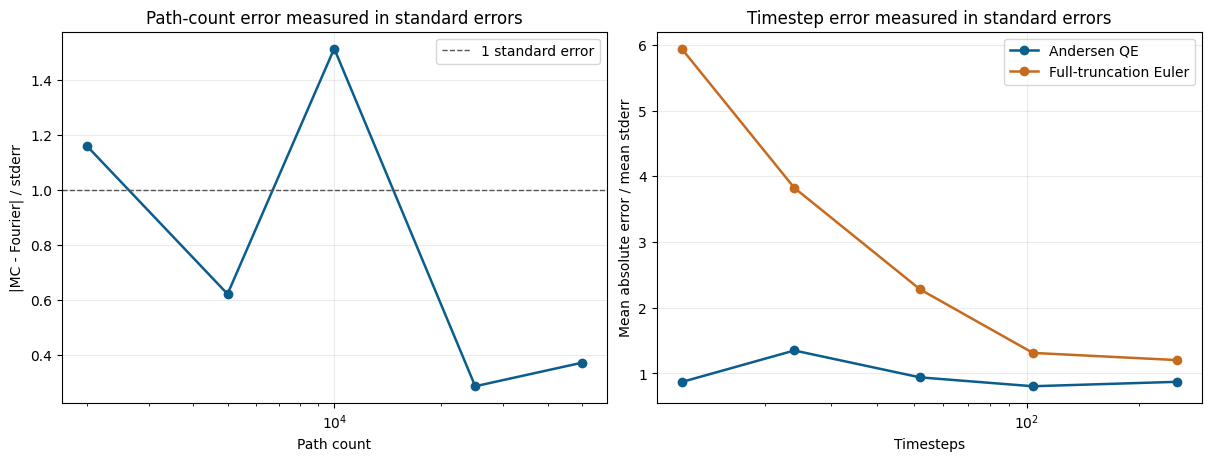

In [8]:
bias_standardized = bias_summary.copy()
bias_standardized["error_in_stderr"] = np.where(
    bias_standardized["mean_stderr"] > 0.0,
    bias_standardized["mean_abs_error"] / bias_standardized["mean_stderr"],
    np.nan,
)

display(
    runtime_summary[
        [
            "scheme",
            "n_steps",
            "mean_runtime_seconds",
            "mean_abs_error",
            "error_per_second",
            "repeat_count",
        ]
    ].sort_values(["scheme", "n_steps"], ignore_index=True)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

axes[0].plot(
    qe_path_count["n_paths"],
    qe_path_count["error_in_stderr"],
    marker="o",
    linewidth=1.8,
    color="#0b5d8c",
)
axes[0].axhline(
    1.0,
    linestyle="--",
    linewidth=1.0,
    color="#555555",
    label="1 standard error",
)
axes[0].set_xscale("log")
axes[0].set_xlabel("Path count")
axes[0].set_ylabel("|MC - Fourier| / stderr")
axes[0].set_title("Path-count error measured in standard errors")
axes[0].grid(True, alpha=0.25)
axes[0].legend()

for scheme, color in (
    ("quadratic_exponential", "#0b5d8c"),
    ("euler_full_truncation", "#c66a1e"),
):
    scheme_rows = bias_standardized.loc[
        bias_standardized["scheme"] == scheme
    ].sort_values("n_steps")
    axes[1].plot(
        scheme_rows["n_steps"],
        scheme_rows["error_in_stderr"],
        marker="o",
        linewidth=1.8,
        color=color,
        label=SCHEME_LABELS[scheme],
    )

axes[1].set_xscale("log")
axes[1].set_xlabel("Timesteps")
axes[1].set_ylabel("Mean absolute error / mean stderr")
axes[1].set_title("Timestep error measured in standard errors")
axes[1].grid(True, alpha=0.25)
axes[1].legend()

plt.show()

**Figure takeaway:** Measuring errors in standard-error units separates estimator noise from raw price units. QE remains close to the Fourier benchmark across the tested grid, while Euler’s coarse-timestep bias is large relative to its reported sampling error.

## Takeaways

- The semi-analytic Fourier pricer is the benchmark for vanilla Heston validation.
- Monte Carlo is slower, but it validates the simulation engine and is the route to path-dependent pricing later.
- Andersen QE is the production candidate in this library; full-truncation Euler is kept as a baseline / educational scheme.
- Standard errors and 95% confidence intervals are part of the estimator, not optional decoration.
- Any remaining gap to the Fourier price should be read as sampling noise plus discretization bias, not hand-waved away.